In [ ]:
from huggingface_hub import notebook_login
notebook_login()


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [ ]:
!git clone https://github.com/minwoosun/UCE.git

Cloning into 'UCE'...
remote: Enumerating objects: 151, done.
remote: Counting objects: 100% (80/80), done.
remote: Compressing objects: 100% (33/33), done.
remote: Total 151 (delta 66), reused 47 (delta 47), pack-reused 71 (from 1)
Receiving objects: 100% (151/151), 67.75 KiB | 1.54 MiB/s, done.
Resolving deltas: 100% (80/80), done.


In [ ]:
%cd UCE

/content/UCE


In [ ]:
! pip install -r requirements.txt

In [ ]:
!pip install harmonypy scib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.6/84.6 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 174.3/174.3 kB 9.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.7/5.7 MB 39.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 37.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 50.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 55.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 183.0/183.0 kB 9.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 295.7/295.7 kB 14.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 25.0 MB/s eta 0:00:00
  Attempting uninstall: pandas
    Found existing installation: pandas 2.2.2
    Uninstalling pandas-2.2.2:
      Successfully uninstall

In [ ]:
!pip install scanpy

In [ ]:
#mount drive
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


### load embeddings

In [ ]:
data_path = "/content/drive/MyDrive/GP_datasets/Lung_embeddings_uce.h5ada"

In [ ]:
import scanpy as sc
import numpy as np
from scipy.sparse import issparse

adata = sc.read_h5ad(data_path)
print(adata)

AnnData object with n_obs × n_vars = 65129 × 12814
    obs: 'cell_type', 'dataset', 'source', 'n_genes'
    var: 'n_cells'
    uns: 'cell_type_colors', 'dataset_colors', 'neighbors', 'pca', 'umap'
    obsm: 'X_pca', 'X_uce', 'X_umap'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'


In [ ]:
# counts layer
adata.layers["counts"] = adata.X.copy()

In [ ]:
!pip install scanpy harmonypy

In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import silhouette_score
from harmonypy import compute_lisi

def compute_silhouette_and_lisi(adata, label_keys, embed_key,k_lisi=30):

    X = adata.obsm[embed_key]
    metadata = adata.obs[label_keys]


    # Silhouette scores
    sil_scores = {}
    for key in label_keys:
        sil_scores[key] = silhouette_score(X, adata.obs[key].values)


    # Call compute_lisi
    lisi_scores = compute_lisi(X, metadata, label_colnames=label_keys)

    # Convert to DataFrame for easier handling
    lisi_df = pd.DataFrame(lisi_scores, columns=label_keys, index=adata.obs_names)

    # Combine results
    scores = {
        "silhouette": sil_scores,
        "lisi": lisi_df.median().to_dict()
    }

    return scores

/usr/local/lib/python3.12/dist-packages/torch/autograd/__init__.py:16: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  from torch import _vmap_internals


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report
adata

AnnData object with n_obs × n_vars = 65129 × 12814
    obs: 'cell_type', 'dataset', 'source', 'n_genes'
    var: 'n_cells'
    uns: 'cell_type_colors', 'dataset_colors', 'neighbors', 'pca', 'umap'
    obsm: 'X_pca', 'X_uce', 'X_umap'
    varm: 'PCs'
    layers: 'counts'
    obsp: 'connectivities', 'distances'

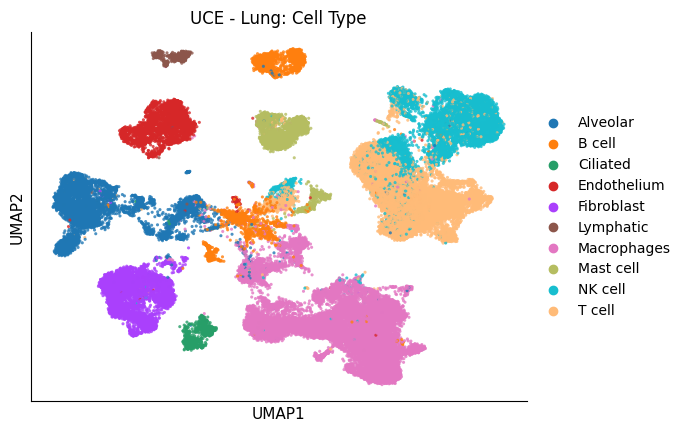

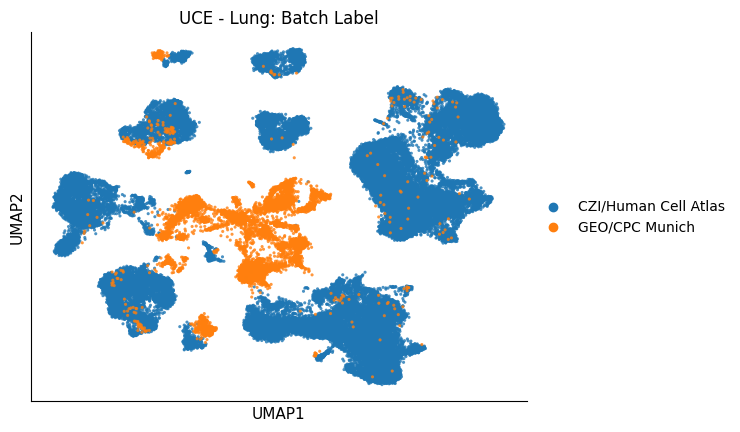

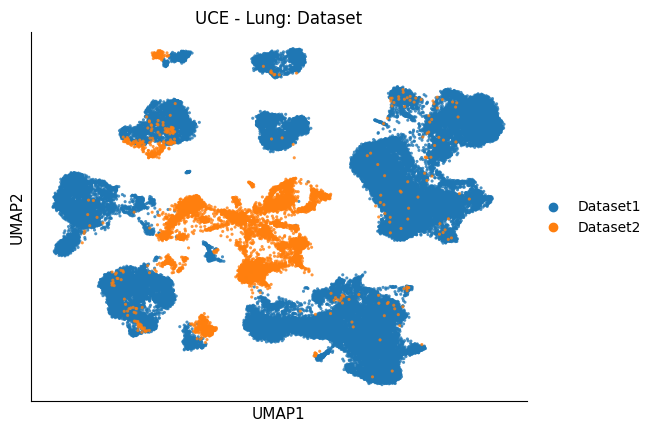

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


=== Logistic Regression ===
Accuracy: 0.7882156753752084
              precision    recall  f1-score   support

    Alveolar       0.56      0.95      0.71      1834
      B cell       0.76      0.04      0.08      1250
    Ciliated       0.99      0.98      0.98       433
 Endothelium       0.94      0.96      0.95       360
  Fibroblast       0.95      0.93      0.94       204
   Lymphatic       1.00      0.97      0.98       195
 Macrophages       0.91      0.94      0.93      2878
   Mast cell       0.97      0.94      0.95       660
     NK cell       0.84      0.57      0.68       354
      T cell       0.77      0.73      0.75       827

    accuracy                           0.79      8995
   macro avg       0.87      0.80      0.80      8995
weighted avg       0.82      0.79      0.75      8995



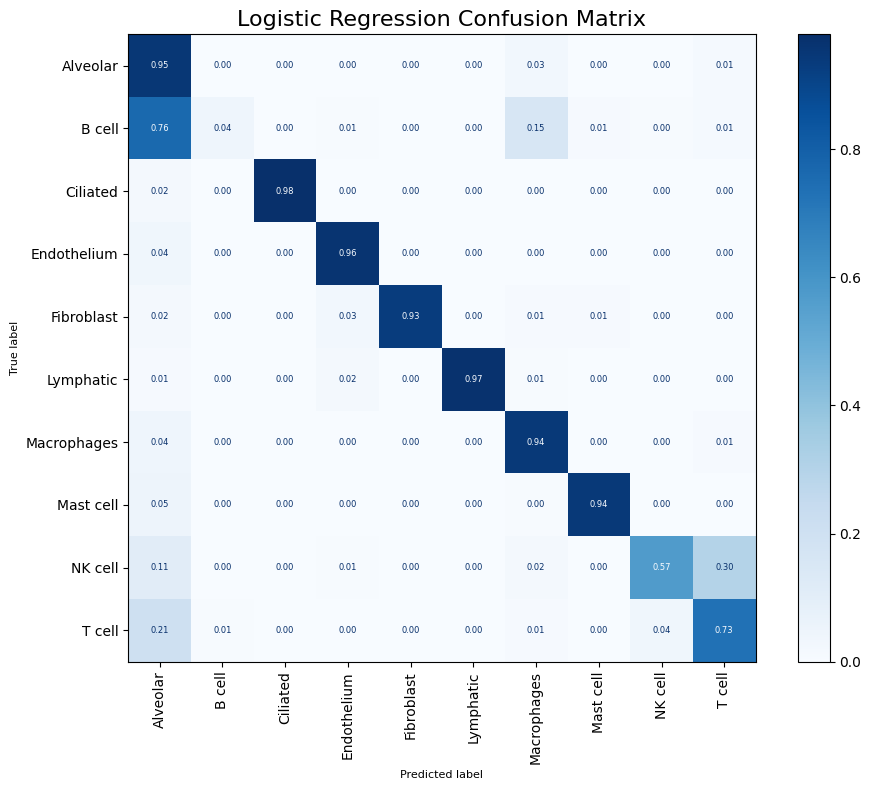


=== k-NN ===
Accuracy: 0.7875486381322957
              precision    recall  f1-score   support

    Alveolar       0.57      0.94      0.71      1834
      B cell       0.82      0.05      0.09      1250
    Ciliated       0.98      0.99      0.98       433
 Endothelium       0.95      0.94      0.95       360
  Fibroblast       0.91      0.94      0.92       204
   Lymphatic       1.00      0.98      0.99       195
 Macrophages       0.90      0.95      0.93      2878
   Mast cell       0.90      0.97      0.94       660
     NK cell       0.82      0.68      0.74       354
      T cell       0.83      0.63      0.71       827

    accuracy                           0.79      8995
   macro avg       0.87      0.81      0.80      8995
weighted avg       0.82      0.79      0.74      8995



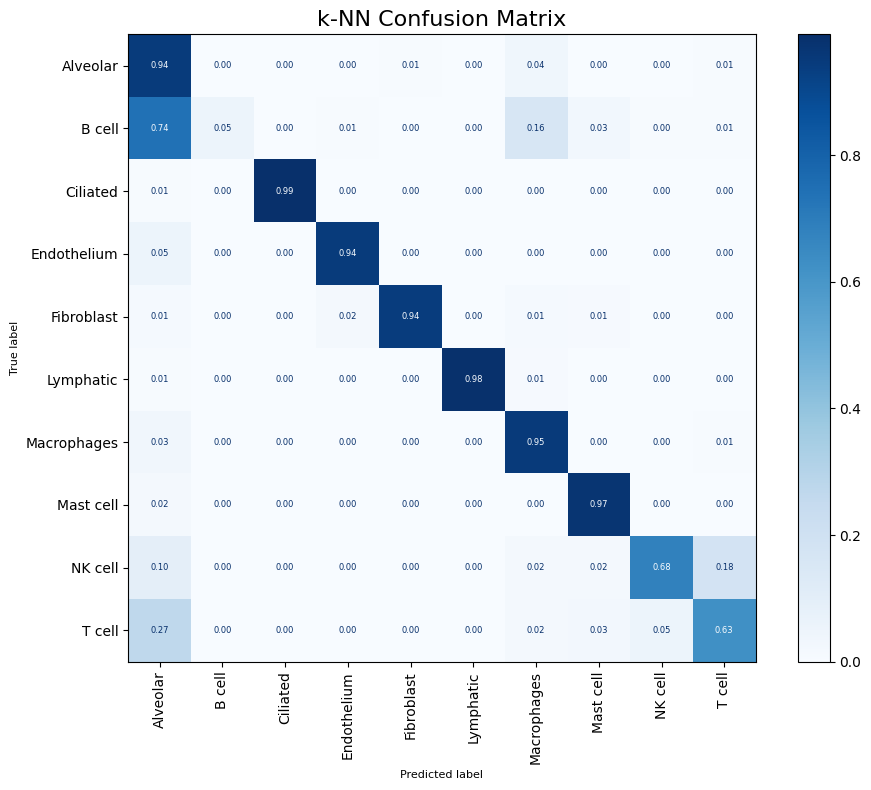

/tmp/ipykernel_53463/2617874866.py:158: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  test_data.obs["y_pred_lr"] = y_pred_lr


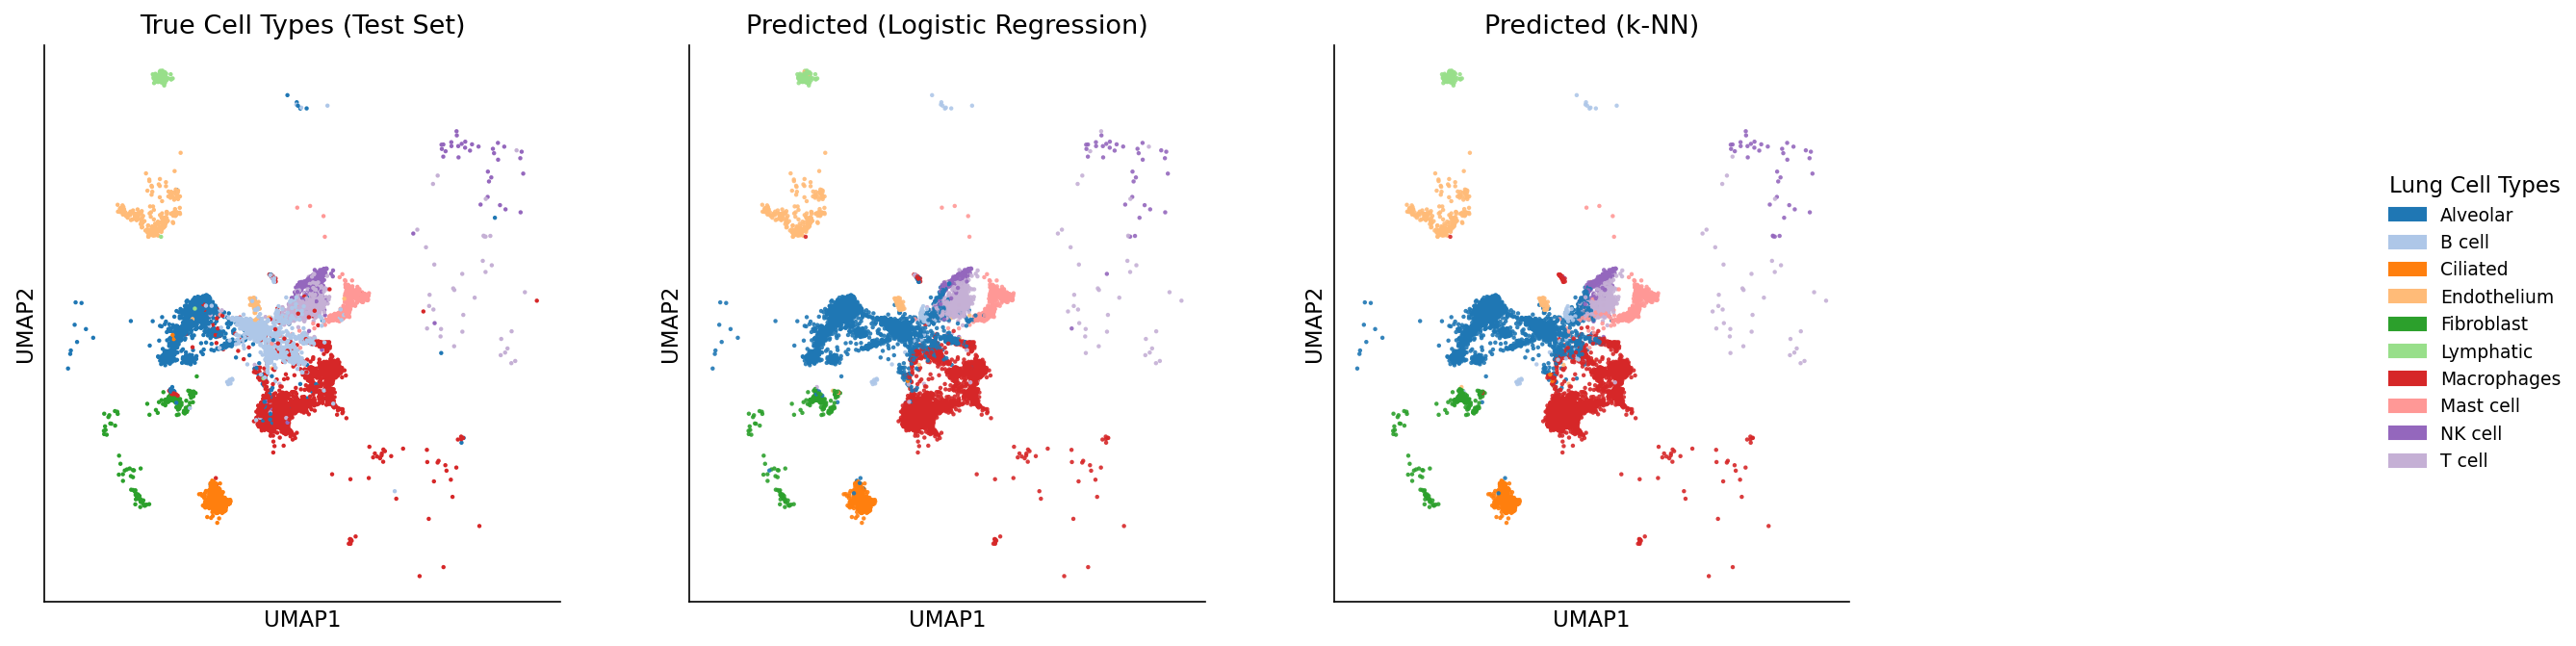

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay
## Visualization

sc.pp.neighbors(adata, use_rep="X_uce")
sc.tl.umap(adata)

ax = sc.pl.umap(
    adata,
    color='cell_type',
    size=20,
    alpha=0.8,
    frameon=True,
    show=False,
    title="UCE - Lung: Cell Type"
)

ax.set_facecolor("white")
ax.set_xlabel("UMAP1", fontsize=11)
ax.set_ylabel("UMAP2", fontsize=11)

# Make axis lines visible
ax.spines[['left', 'bottom']].set_visible(True)

# Remove top/right box lines (clean style)
ax.spines[['top', 'right']].set_visible(False)

# Make axes black
ax.spines[['left', 'bottom']].set_color("black")

plt.show()

ax = sc.pl.umap(
    adata,
    color='source',
    size=20,
    alpha=0.8,
    frameon=True,
    show=False,
    title="UCE - Lung: Batch Label"
)

ax.set_facecolor("white")
ax.set_xlabel("UMAP1", fontsize=11)
ax.set_ylabel("UMAP2", fontsize=11)

# Make axis lines visible
ax.spines[['left', 'bottom']].set_visible(True)

# Remove top/right box lines (clean style)
ax.spines[['top', 'right']].set_visible(False)

# Make axes black
ax.spines[['left', 'bottom']].set_color("black")

plt.show()

ax = sc.pl.umap(
    adata,
    color='dataset',
    size=20,
    alpha=0.8,
    frameon=True,
    show=False,
    title="UCE - Lung: Dataset"
)

ax.set_facecolor("white")
ax.set_xlabel("UMAP1", fontsize=11)
ax.set_ylabel("UMAP2", fontsize=11)

# Make axis lines visible
ax.spines[['left', 'bottom']].set_visible(True)

# Remove top/right box lines (clean style)
ax.spines[['top', 'right']].set_visible(False)

# Make axes black
ax.spines[['left', 'bottom']].set_color("black")

plt.show()

## Build a cell-type classifier using Geneformer embeddings  3 batches for train and 1 for test

train_data = adata[adata.obs["dataset"] == "Dataset1"]
test_data = adata[adata.obs["dataset"] == "Dataset2"]
X_train = train_data.obsm["X_uce"]
X_test  = test_data.obsm["X_uce"]

y_train = train_data.obs["cell_type"]
y_test  = test_data.obs["cell_type"]


# logistic regression
clf = LogisticRegression(max_iter=300, multi_class='multinomial', solver='lbfgs')

clf.fit(X_train, y_train)
y_pred_lr = clf.predict(X_test)

# KNN
knn = KNeighborsClassifier(
    n_neighbors=15,
    weights="distance",
    metric="cosine"
)

knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)

def plot_cm(y_true, y_pred, title):
    # Reset to default style to ensure consistency
    plt.rcdefaults()
    plt.rcParams.update({
        'figure.facecolor': 'white',
        'axes.facecolor': 'white',
        'font.family': 'sans-serif',
        'font.size': 10,
    })

    labels = np.unique(y_true)
    cm = confusion_matrix(y_true, y_pred, labels=labels, normalize="true")

    fig, ax = plt.subplots(figsize=(10, 8), dpi=100)

    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
    disp.plot(
        ax=ax,
        cmap="Blues",
        xticks_rotation=90,
        values_format=".2f",
        colorbar=True
    )
    ax.grid(False)

    for text in ax.texts:
        text.set_fontsize(6)

    plt.title(title, fontsize=16)
    plt.xlabel("Predicted label", fontsize=8)
    plt.ylabel("True label", fontsize=8)

    plt.tight_layout()
    plt.show()

print("=== Logistic Regression ===")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))
plot_cm(y_test, y_pred_lr, "Logistic Regression Confusion Matrix")


print("\n=== k-NN ===")
print("Accuracy:", accuracy_score(y_test, y_pred_knn))
print(classification_report(y_test, y_pred_knn))
plot_cm(y_test, y_pred_knn, "k-NN Confusion Matrix")

# Attach predictions to test dataset
test_data.obs["y_pred_lr"] = y_pred_lr
test_data.obs["y_pred_knn"] = y_pred_knn

# Fill missing values
test_data.obs["y_pred_lr"] = test_data.obs["y_pred_lr"].astype(str).fillna("Unassigned")
test_data.obs["y_pred_knn"] = test_data.obs["y_pred_knn"].astype(str).fillna("Unassigned")

# Convert to categorical
test_data.obs["celltype"] = test_data.obs["cell_type"].astype("category") # Changed from celltype to cell_type
test_data.obs["y_pred_lr"] = test_data.obs["y_pred_lr"].astype("category")
test_data.obs["y_pred_knn"] = test_data.obs["y_pred_knn"].astype("category")

# Unified label set
all_labels = sorted(
    set(test_data.obs["celltype"].cat.categories)
    | set(test_data.obs["y_pred_lr"].cat.categories)
    | set(test_data.obs["y_pred_knn"].cat.categories)
)

# Force same category order
test_data.obs["celltype"] = test_data.obs["celltype"].cat.set_categories(all_labels)
test_data.obs["y_pred_lr"] = test_data.obs["y_pred_lr"].cat.set_categories(all_labels)
test_data.obs["y_pred_knn"] = test_data.obs["y_pred_knn"].cat.set_categories(all_labels)

# Color map
palette = sc.pl.palettes.vega_20
color_map = {label: palette[i % len(palette)] for i, label in enumerate(all_labels)}
color_map["Unassigned"] = "lightgray"

# Plot
fig, axes = plt.subplots(1, 3, figsize=(20, 5), dpi=150)

common_kwargs = dict(
    show=False,
    size=18,
    frameon=True,
    palette=color_map
)

# True labels
sc.pl.umap(test_data, color="celltype", ax=axes[0], **common_kwargs)
axes[0].set_title("True Cell Types (Test Set)", fontsize=13)

# Logistic Regression predictions
sc.pl.umap(test_data, color="y_pred_lr", ax=axes[1], alpha=0.9, **common_kwargs)
axes[1].set_title("Predicted (Logistic Regression)", fontsize=13)

# KNN predictions
sc.pl.umap(test_data, color="y_pred_knn", ax=axes[2], alpha=0.9, **common_kwargs)
axes[2].set_title("Predicted (k-NN)", fontsize=13)

# Remove auto legends
for ax in axes:
    # Remove auto legend
    if ax.legend_:
        ax.legend_.remove()

    # Force white background
    ax.set_facecolor("white")

    # Axis labels
    ax.set_xlabel("UMAP1", fontsize=11)
    ax.set_ylabel("UMAP2", fontsize=11)

    # Make axis lines visible
    ax.spines[['left', 'bottom']].set_visible(True)

    # Remove top/right box lines (clean style)
    ax.spines[['top', 'right']].set_visible(False)

    # Make axes black
    ax.spines[['left', 'bottom']].set_color("black")

    # Ticks
    ax.tick_params(
        axis='both',
        which='major',
        labelsize=9,
        colors='black'
    )
# Single clean legend
from matplotlib.patches import Patch
handles = [Patch(color=color_map[label], label=label) for label in all_labels]
fig.legend(
    handles=handles,
    title="Lung Cell Types",
    loc="center right",
    frameon=False,
    fontsize=9,
    title_fontsize=11,
    ncol=1
)
plt.subplots_adjust(right=0.75, wspace=0.25)
# plt.tight_layout()
plt.show()

In [ ]:
# scores for lung

label_keys = ["cell_type","dataset"]
# Compute scores
scores = compute_silhouette_and_lisi(adata, label_keys, embed_key="X_uce", k_lisi=30)
print("Silhouette Scores:", scores["silhouette"])
print("LISI Scores:", scores["lisi"])